In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Analyse de forme et des variables
#### Target : colonne 41 (on construit donc une colonne attack a travers cette colonne qui prend 0 si normal et 1 sinn)
#### dataset shape : (125973, 43)
#### dataset variables types : float : 15, int : 24, str : 4
#### target distribution : 53,4% nomral et 46,5% attack


In [30]:
df_0 = pd.read_csv('data/KDDTrain+.txt', header=None)
df = df_0.copy()
df[41].value_counts()
df = df.rename(columns={41: 'attack type'})
df['attack type'] = df['attack type'].apply(lambda x: 0 if x == 'normal' else 1)
df.head()
attack = df['attack type'].value_counts()
attack_percent = attack / len(df)
attack_percent

attack type
0    0.534583
1    0.465417
Name: count, dtype: float64

<Axes: xlabel='protocole_type'>

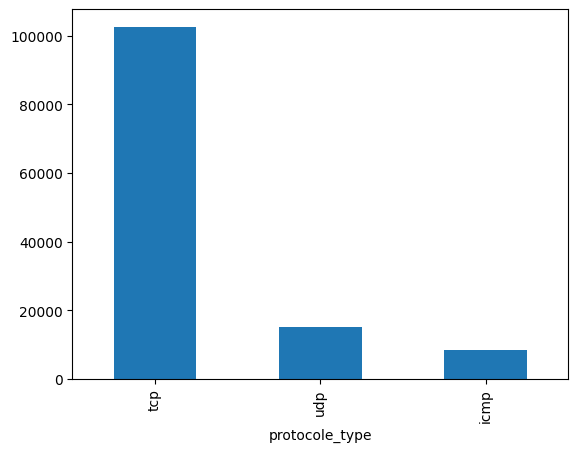

In [31]:
df = df.rename(columns={'protocol_type': 'service'})
df = df.rename(columns={1: 'protocole_type'})
df['protocole_type'].value_counts().plot(kind='bar')

In [32]:

columns = (['duration'
,'protocol_type'
,'service'
,'flag'
,'src_bytes'
,'dst_bytes'
,'land'
,'wrong_fragment'
,'urgent'
,'hot'
,'num_failed_logins'
,'logged_in'
,'num_compromised'
,'root_shell'
,'su_attempted'
,'num_root'
,'num_file_creations'
,'num_shells'
,'num_access_files'
,'num_outbound_cmds'
,'is_host_login'
,'is_guest_login'
,'count'
,'srv_count'
,'serror_rate'
,'srv_serror_rate'
,'rerror_rate'
,'srv_rerror_rate'
,'same_srv_rate'
,'diff_srv_rate'
,'srv_diff_host_rate'
,'dst_host_count'
,'dst_host_srv_count'
,'dst_host_same_srv_rate'
,'dst_host_diff_srv_rate'
,'dst_host_same_src_port_rate'
,'dst_host_srv_diff_host_rate'
,'dst_host_serror_rate'
,'dst_host_srv_serror_rate'
,'dst_host_rerror_rate'
,'dst_host_srv_rerror_rate'
,'attack'
,'level'])
df.columns = columns
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,0,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,0,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,1,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,0,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,21


<Figure size 600x400 with 0 Axes>

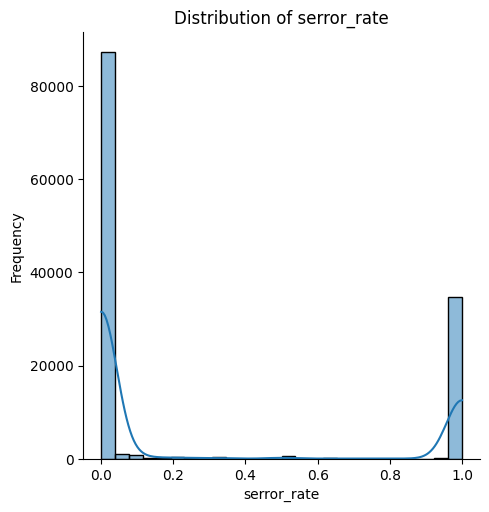

<Figure size 600x400 with 0 Axes>

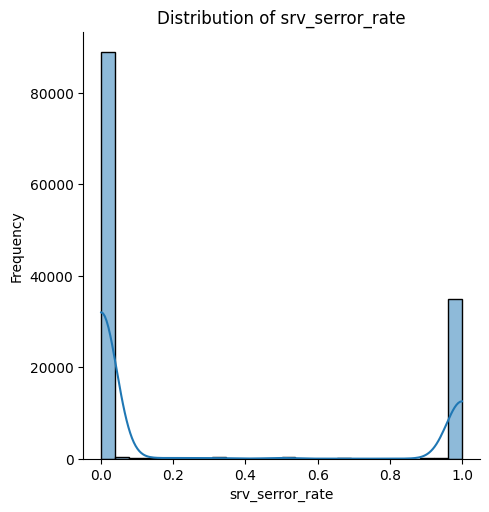

<Figure size 600x400 with 0 Axes>

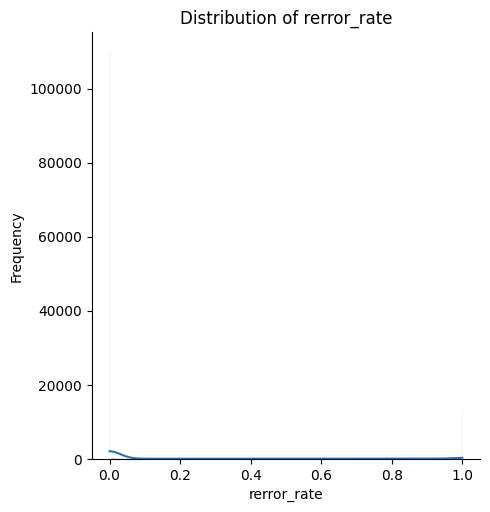

<Figure size 600x400 with 0 Axes>

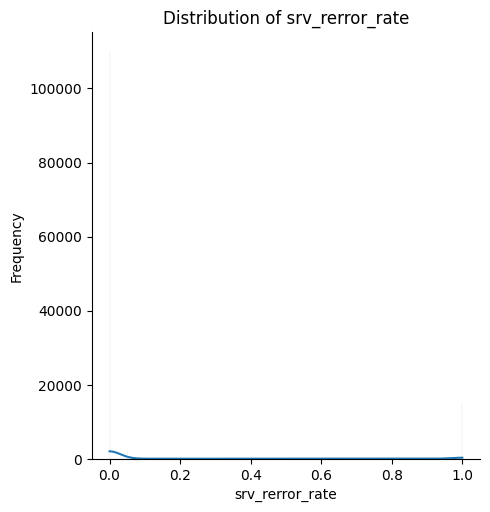

<Figure size 600x400 with 0 Axes>

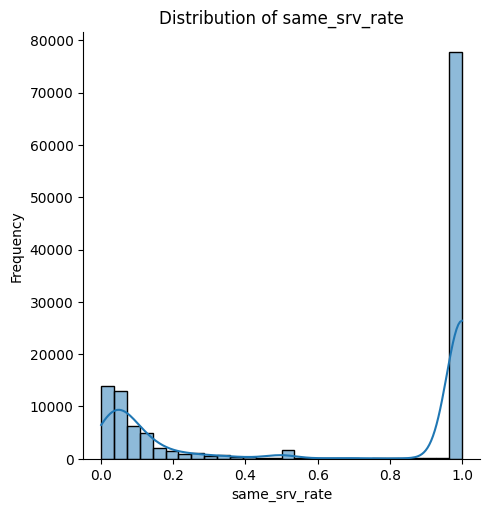

<Figure size 600x400 with 0 Axes>

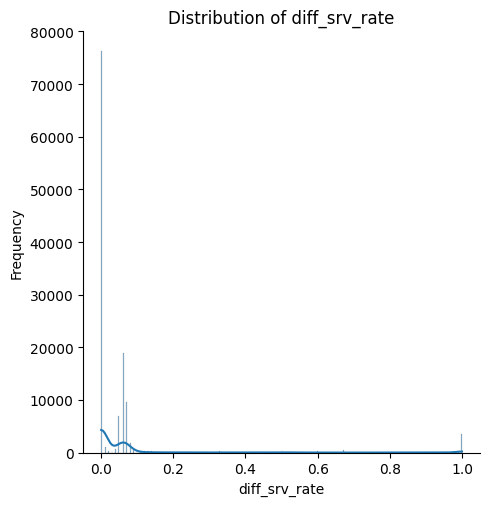

<Figure size 600x400 with 0 Axes>

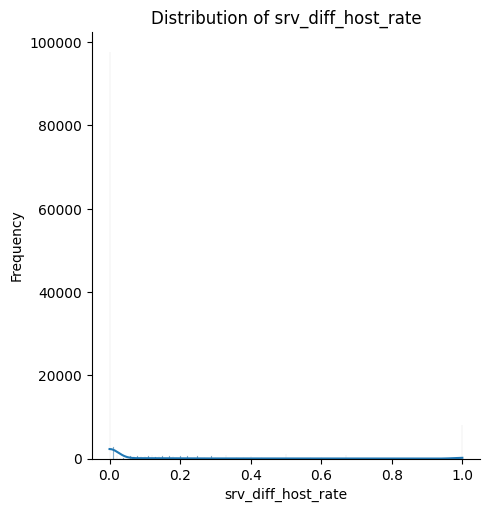

<Figure size 600x400 with 0 Axes>

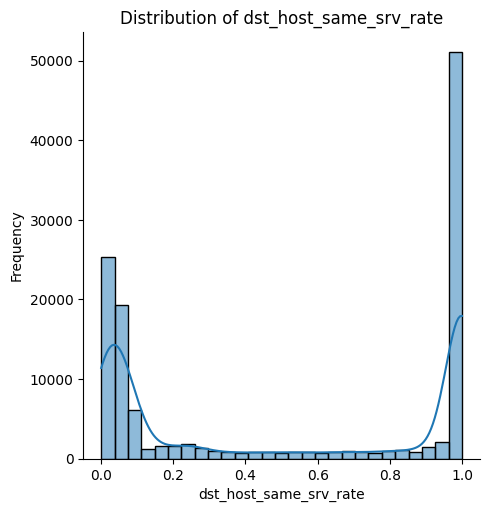

<Figure size 600x400 with 0 Axes>

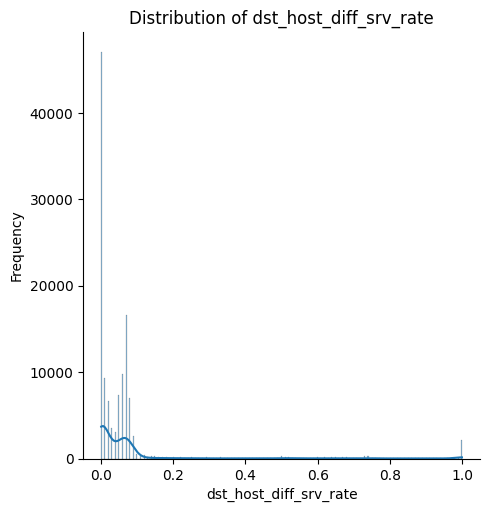

<Figure size 600x400 with 0 Axes>

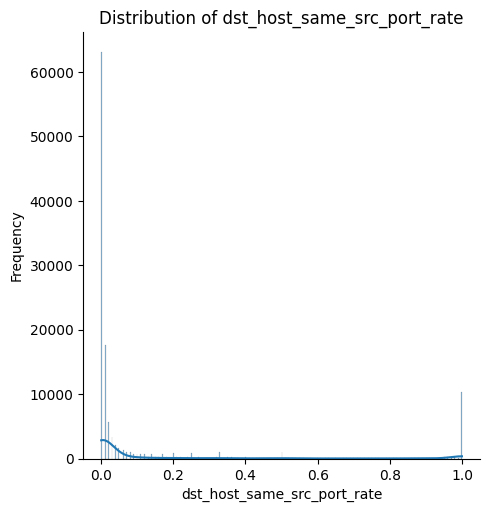

<Figure size 600x400 with 0 Axes>

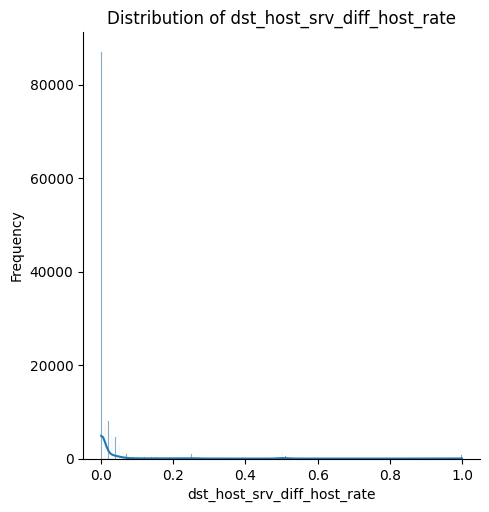

<Figure size 600x400 with 0 Axes>

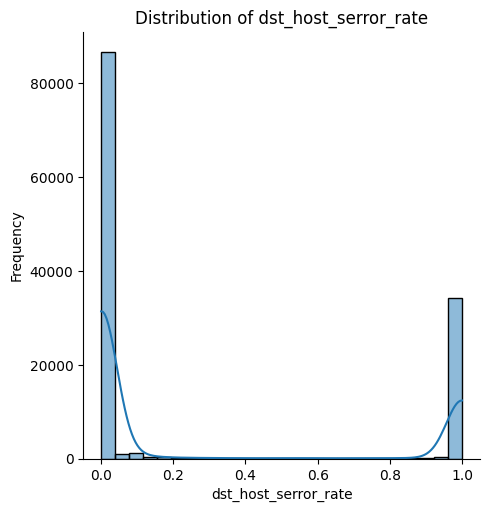

<Figure size 600x400 with 0 Axes>

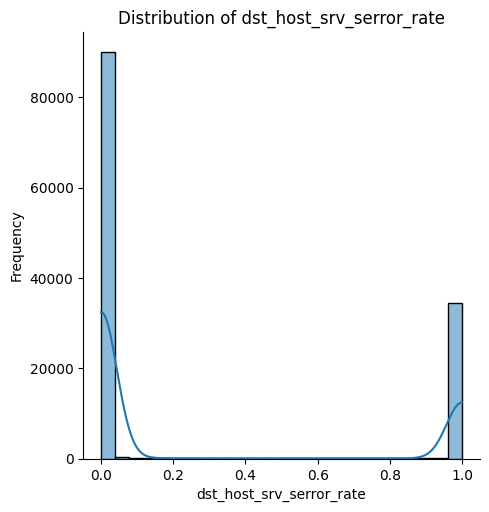

<Figure size 600x400 with 0 Axes>

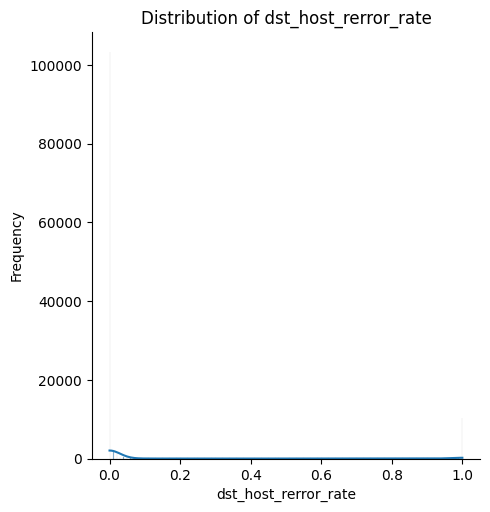

<Figure size 600x400 with 0 Axes>

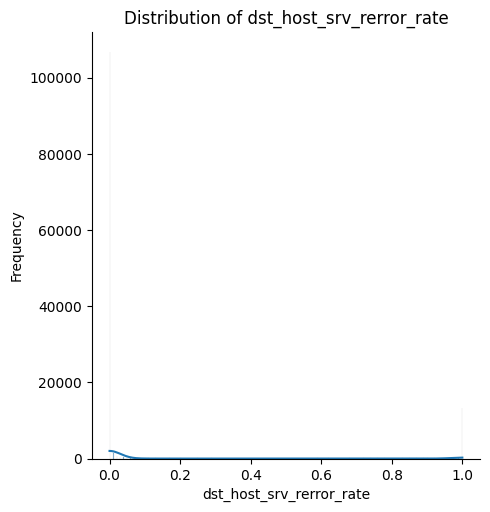

In [33]:
for col in df.select_dtypes('float'):
    plt.figure(figsize=(6, 4))
    sns.displot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()  


## Analyse variables target
#### variables quantittive : les variables importants : serror_rate, same_srv_rate, diff_srv_rate, dst_host_diff_srv_rate
#### variables qualitatives string: tous sont importantes
#### variables entiers : variables non importants sont :land, logged_in, roote_shell, num_shells, is_gast_logging, num_bound_cmds, count,srv_count, dst_host_count, dst_host_srv_count

In [34]:


# 1. Sélectionner uniquement les colonnes numériques pour le calcul
df_numeric = df.select_dtypes(include=[np.number])

# 2. Calculer la matrice de corrélation en valeur absolue
corr_matrix = df_numeric.corr().abs()

# 3. Créer un masque pour ne regarder que le triangle supérieur de la matrice
# (Cela permet de ne pas comparer une colonne avec elle-même ou de voir les paires deux fois)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 4. Identifier les colonnes à supprimer (seuil > 0.9)
to_drop = [column for column in upper.columns if any(upper[column] > 0.93)]

# 5. [OPTIONNEL MAIS RECOMMANDÉ] Identifier les colonnes avec zero variance (que des 0)
# Ce sont elles qui créent les "NaN" dans votre matrice
constant_cols = [col for col in df_numeric.columns if df_numeric[col].nunique() <= 1]

# 6. Fusionner les listes de colonnes à supprimer (sans doublons)
total_drop = list(set(to_drop + constant_cols))

# 7. Créer le nouveau DataFrame nettoyé
df_cleaned = df.drop(columns=total_drop)

df = df_cleaned
df.drop(columns=['land', 'logged_in', 'root_shell', 'num_shells', 'is_guest_login', 'count','srv_count', 'dst_host_count', 'dst_host_srv_count'], inplace=True)


C:\Users\trins\AppData\Local\Temp\ipykernel_5428\730282149.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_normal[col], kde=True)
C:\Users\trins\AppData\Local\Temp\ipykernel_5428\730282149.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_attack[col], kde=True)


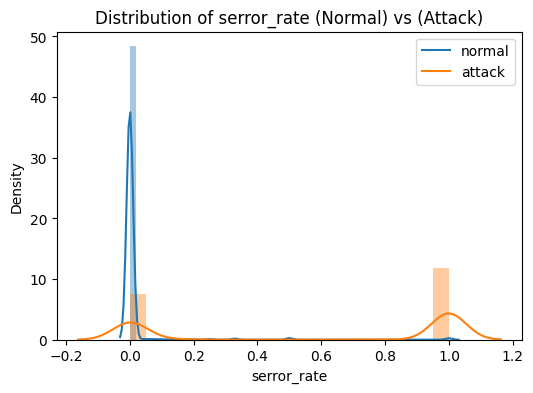

C:\Users\trins\AppData\Local\Temp\ipykernel_5428\730282149.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_normal[col], kde=True)
C:\Users\trins\AppData\Local\Temp\ipykernel_5428\730282149.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_attack[col], kde=True)


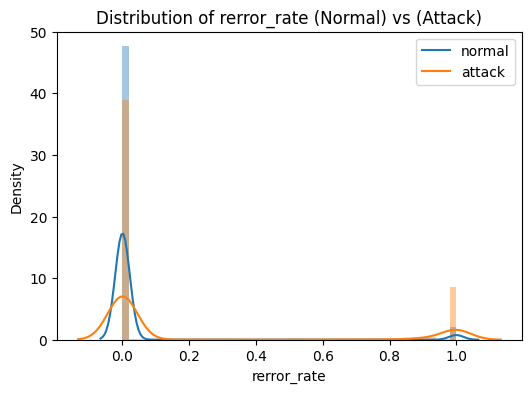

C:\Users\trins\AppData\Local\Temp\ipykernel_5428\730282149.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_normal[col], kde=True)
C:\Users\trins\AppData\Local\Temp\ipykernel_5428\730282149.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_attack[col], kde=True)


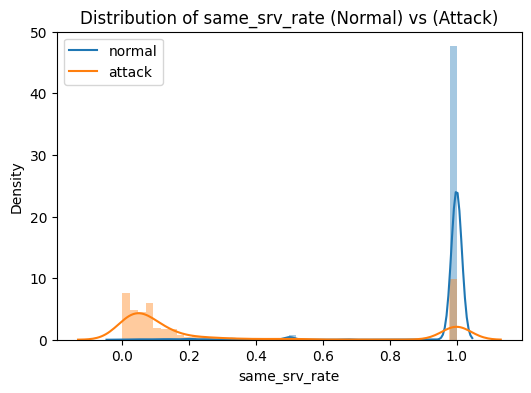

C:\Users\trins\AppData\Local\Temp\ipykernel_5428\730282149.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_normal[col], kde=True)
C:\Users\trins\AppData\Local\Temp\ipykernel_5428\730282149.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_attack[col], kde=True)


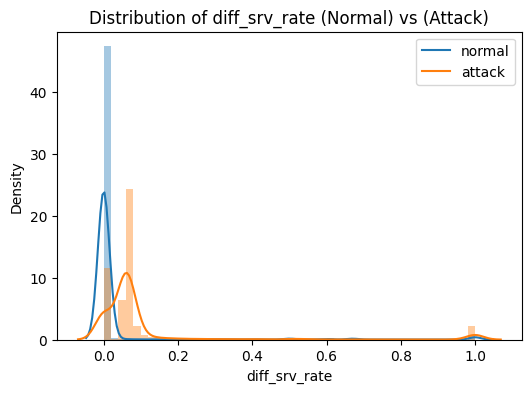

C:\Users\trins\AppData\Local\Temp\ipykernel_5428\730282149.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_normal[col], kde=True)
C:\Users\trins\AppData\Local\Temp\ipykernel_5428\730282149.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_attack[col], kde=True)


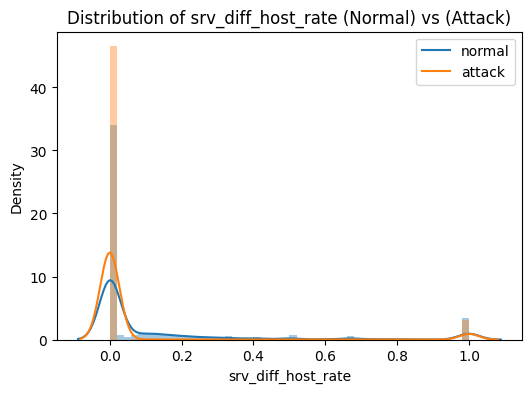

C:\Users\trins\AppData\Local\Temp\ipykernel_5428\730282149.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_normal[col], kde=True)
C:\Users\trins\AppData\Local\Temp\ipykernel_5428\730282149.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_attack[col], kde=True)


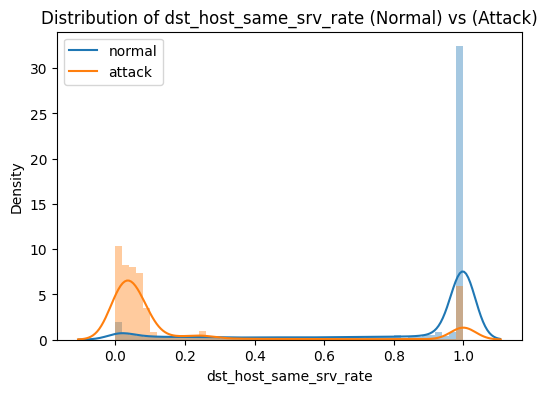

C:\Users\trins\AppData\Local\Temp\ipykernel_5428\730282149.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_normal[col], kde=True)
C:\Users\trins\AppData\Local\Temp\ipykernel_5428\730282149.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_attack[col], kde=True)


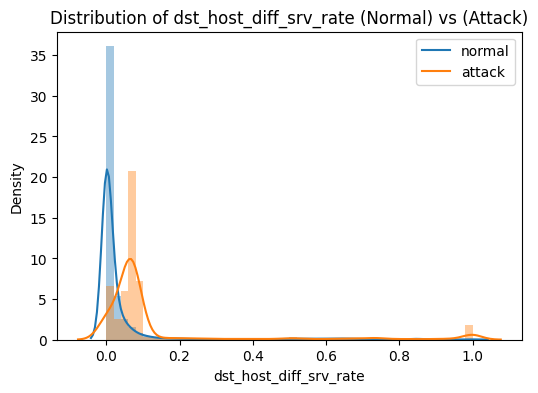

C:\Users\trins\AppData\Local\Temp\ipykernel_5428\730282149.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_normal[col], kde=True)
C:\Users\trins\AppData\Local\Temp\ipykernel_5428\730282149.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_attack[col], kde=True)


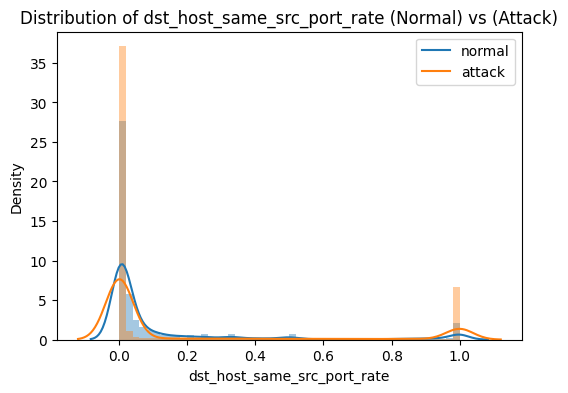

C:\Users\trins\AppData\Local\Temp\ipykernel_5428\730282149.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_normal[col], kde=True)
C:\Users\trins\AppData\Local\Temp\ipykernel_5428\730282149.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_attack[col], kde=True)


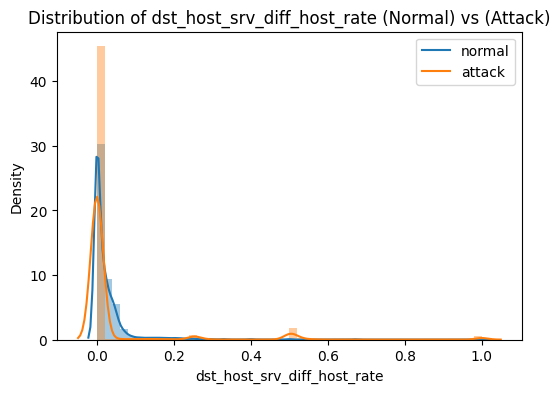

C:\Users\trins\AppData\Local\Temp\ipykernel_5428\730282149.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_normal[col], kde=True)
C:\Users\trins\AppData\Local\Temp\ipykernel_5428\730282149.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_attack[col], kde=True)


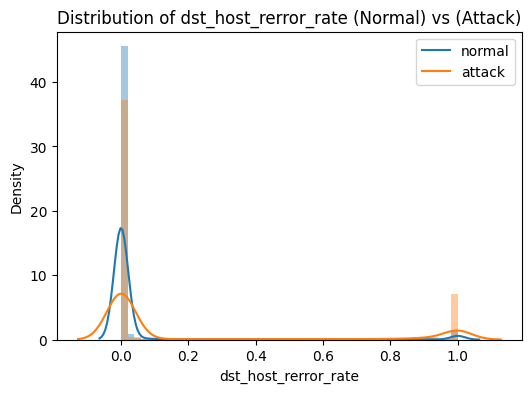

In [35]:
df_normal = df[df['attack'] == 0]
df_attack = df[df['attack'] == 1]
for col in df.select_dtypes('float'):
    plt.figure(figsize=(6, 4))
    sns.distplot(df_normal[col], kde=True)
    sns.distplot(df_attack[col], kde=True)
    plt.title(f"Distribution of {col} (Normal) vs (Attack)")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend(['normal', 'attack'])
    plt.show()


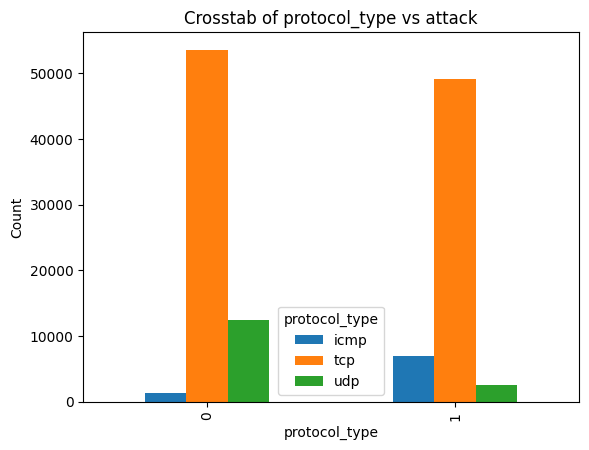

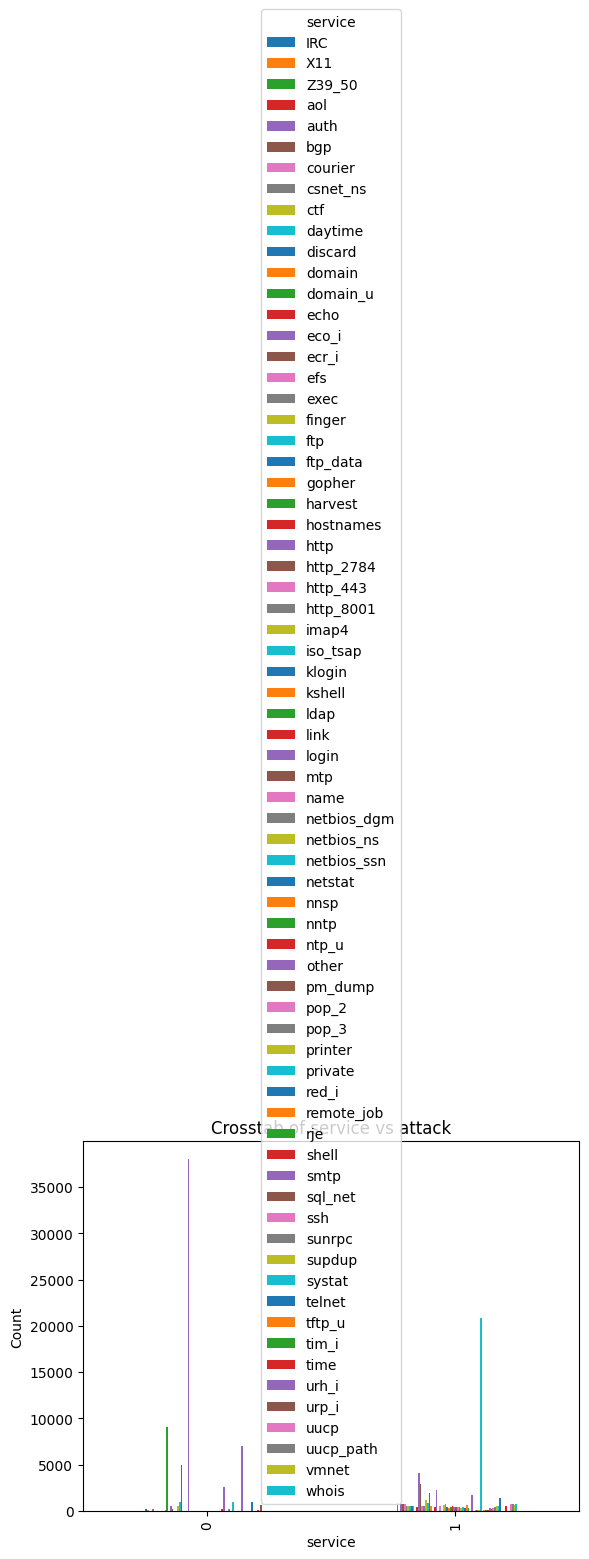

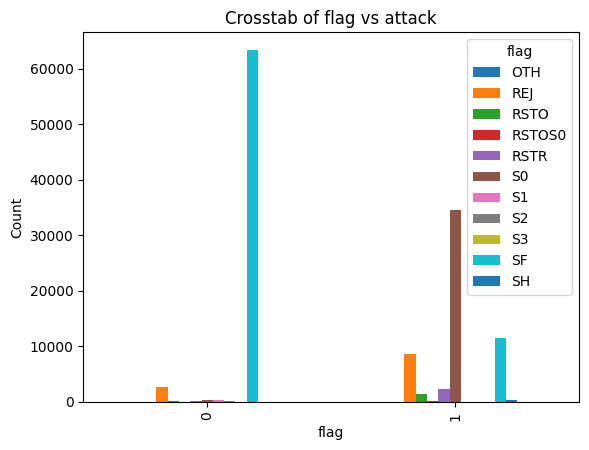

In [36]:

for col in df.select_dtypes('string'):
    pd.crosstab(df['attack'], df[col]).plot.bar()
    plt.title(f"Crosstab of {col} vs attack")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

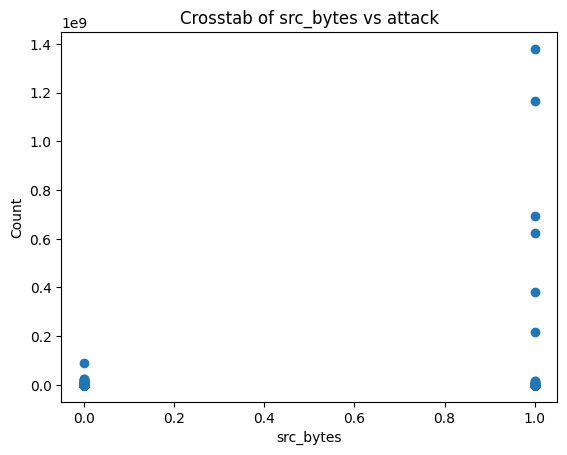

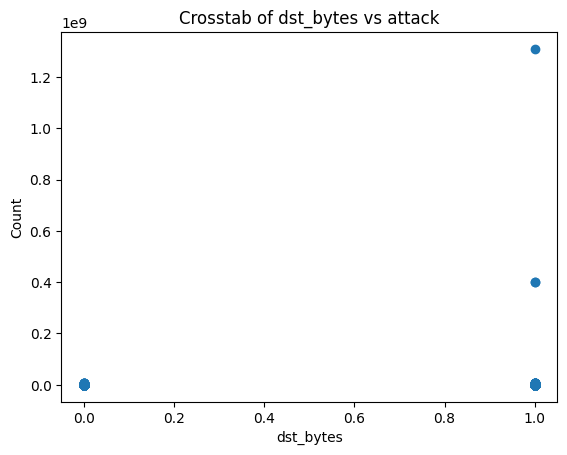

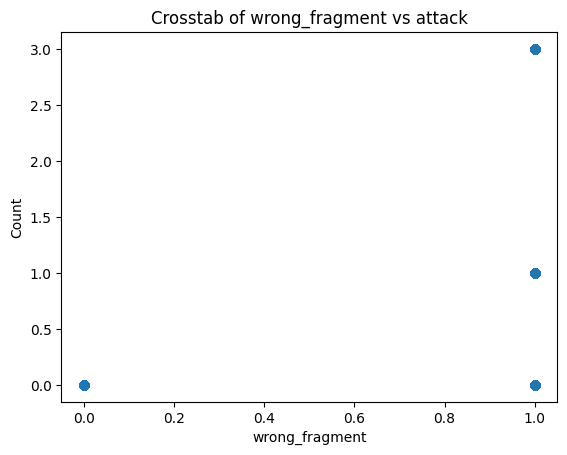

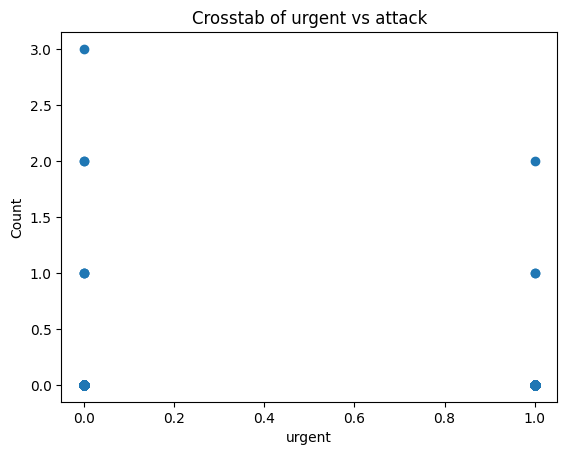

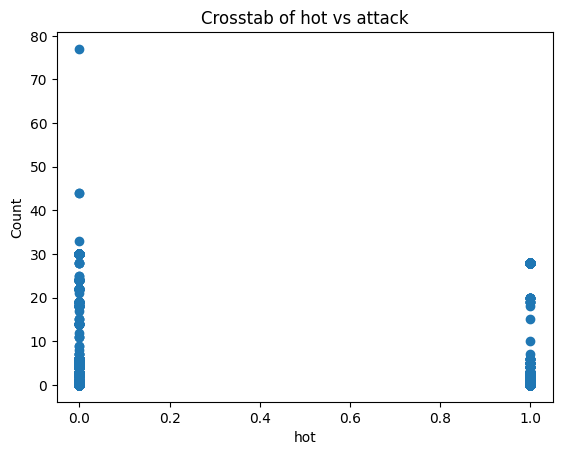

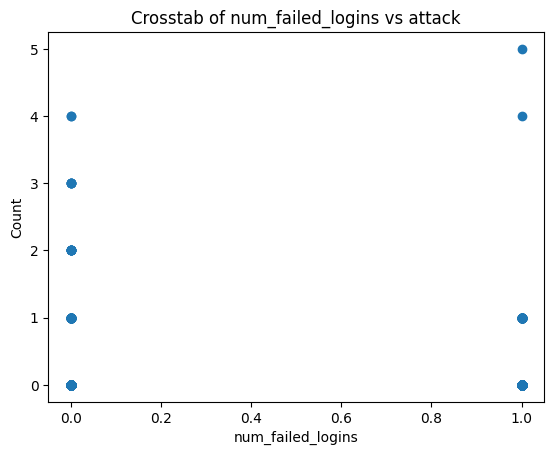

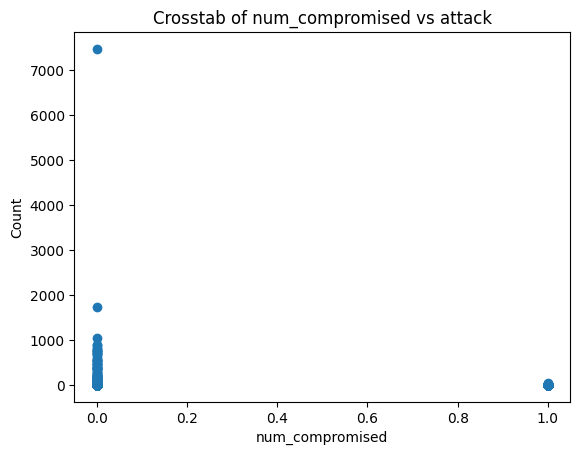

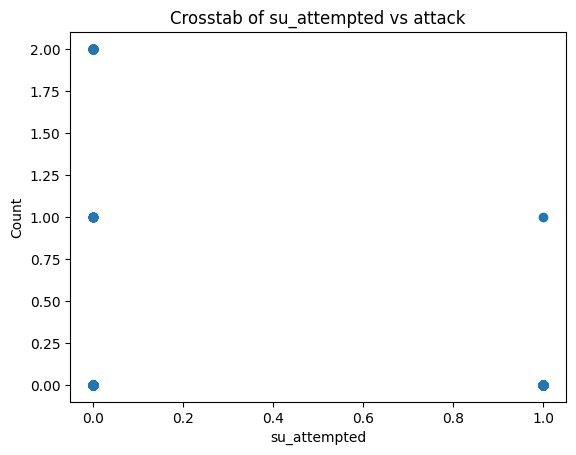

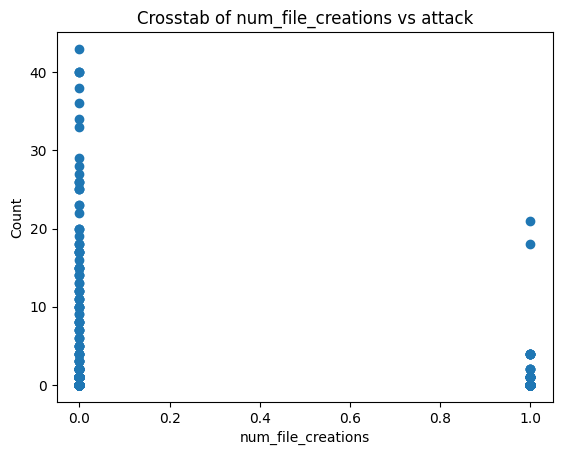

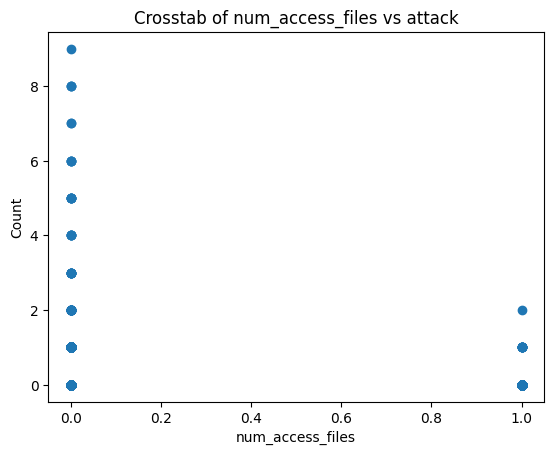

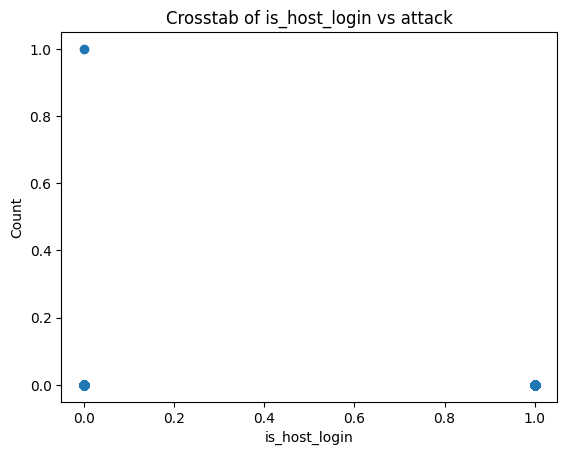

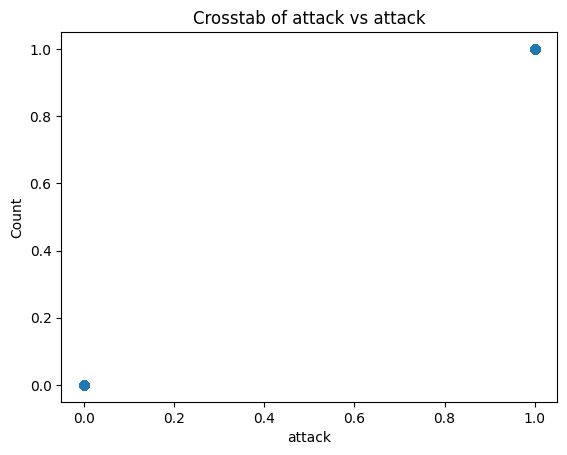

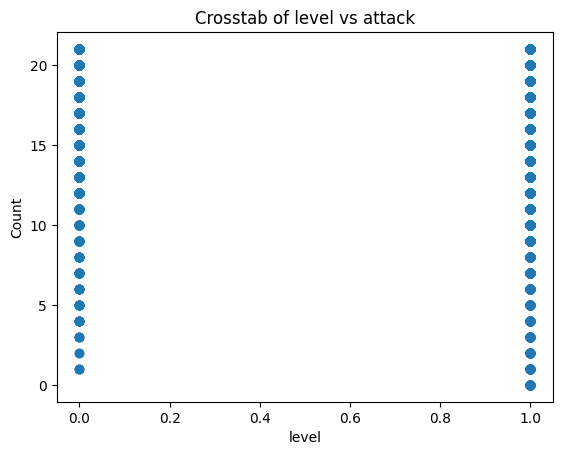

In [37]:
df_without_duration = df_cleaned.drop(columns=['duration'])
for col in df_without_duration.select_dtypes('int'):
    plt.plot(df_without_duration['attack'], df_without_duration[col],'o')
    plt.title(f"Crosstab of {col} vs attack")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

In [38]:
!pip install xgboost

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import learning_curve
from xgboost import XGBClassifier


In [40]:

string_cols = df.select_dtypes('string').columns
preprocessor = LabelEncoder()
for col in string_cols:
    df[col] = preprocessor.fit_transform(df[col])

In [41]:
for col in df.select_dtypes('int'):
   print(col,df[col].unique().sum())
to_standarizer = df.select_dtypes('int').columns.drop(['attack','protocol_type','service','flag','wrong_fragment','urgent','num_failed_logins','num_access_files','su_attempted','is_host_login'])
float_cols = df.select_dtypes('float').columns
to_standarizer = to_standarizer.append(float_cols)
to_standarizer
scaler = StandardScaler()
df[to_standarizer] = scaler.fit_transform(df[to_standarizer])
df.shape


duration 34533315
protocol_type 3
service 2415
flag 55
src_bytes 4839071776
dst_bytes 1988882990
wrong_fragment 4
urgent 6
hot 485
num_failed_logins 15
num_compromised 31976
su_attempted 3
num_file_creations 635
num_access_files 45
is_host_login 1
attack 1
level 231


(125973, 27)

In [47]:
# Ratio de bytes : asymétrie du trafic
df['bytes_ratio'] = df['src_bytes'] / (df['dst_bytes'] + 1)  # +1 pour éviter division par 0

# Ratio erreurs
df['error_ratio'] = df['serror_rate'] / (df['rerror_rate'] + 0.001)
# Log pour les distributions très skewed
df['log_src_bytes'] = np.log1p(df['src_bytes'])     # log(1+x)
df['log_dst_bytes'] = np.log1p(df['dst_bytes'])
df['log_duration'] = np.log1p(df['duration'])

In [54]:
data_test = pd.read_csv('data/KDDTest+.txt', header=None)
def preprocessing(df):
    
    columns = (['duration'
    ,'protocol_type'
    ,'service'
    ,'flag'
    ,'src_bytes'
    ,'dst_bytes'
    ,'land'
    ,'wrong_fragment'
    ,'urgent'
    ,'hot'
    ,'num_failed_logins'
    ,'logged_in'
    ,'num_compromised'
    ,'root_shell'
    ,'su_attempted'
    ,'num_root'
    ,'num_file_creations'
    ,'num_shells'
    ,'num_access_files'
    ,'num_outbound_cmds'
    ,'is_host_login'
    ,'is_guest_login'
    ,'count'
    ,'srv_count'
    ,'serror_rate'
    ,'srv_serror_rate'
    ,'rerror_rate'
    ,'srv_rerror_rate'
    ,'same_srv_rate'
    ,'diff_srv_rate'
    ,'srv_diff_host_rate'
    ,'dst_host_count'
    ,'dst_host_srv_count'
    ,'dst_host_same_srv_rate'
    ,'dst_host_diff_srv_rate'
    ,'dst_host_same_src_port_rate'
    ,'dst_host_srv_diff_host_rate'
    ,'dst_host_serror_rate'
    ,'dst_host_srv_serror_rate'
    ,'dst_host_rerror_rate'
    ,'dst_host_srv_rerror_rate'
    ,'attack'
    ,'level'])
    df.columns = columns
    df['attack'] = df['attack'].apply(lambda x: 0 if x == 'normal' else 1)

# 1. Sélectionner uniquement les colonnes numériques pour le calcul
    df_numeric = df.select_dtypes(include=[np.number])

# 2. Calculer la matrice de corrélation en valeur absolue
    corr_matrix = df_numeric.corr().abs()

# 3. Créer un masque pour ne regarder que le triangle supérieur de la matrice
# (Cela permet de ne pas comparer une colonne avec elle-même ou de voir les paires deux fois)
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 4. Identifier les colonnes à supprimer (seuil > 0.9)
    to_drop = [column for column in upper.columns if any(upper[column] > 0.93)]

# 5. [OPTIONNEL MAIS RECOMMANDÉ] Identifier les colonnes avec zero variance (que des 0)
# Ce sont elles qui créent les "NaN" dans votre matrice
    constant_cols = [col for col in df_numeric.columns if df_numeric[col].nunique() <= 1]

# 6. Fusionner les listes de colonnes à supprimer (sans doublons)
    total_drop = list(set(to_drop + constant_cols))

# 7. Créer le nouveau DataFrame nettoyé
    df_cleaned = df.drop(columns=total_drop)

    df = df_cleaned
    df.drop(columns=['land', 'logged_in', 'root_shell', 'num_shells', 'is_guest_login', 'count','srv_count', 'dst_host_count', 'dst_host_srv_count'], inplace=True)
    string_cols = df.select_dtypes('string').columns
    preprocessor = LabelEncoder()
    for col in string_cols:
        df[col] = preprocessor.fit_transform(df[col])
    df['bytes_ratio'] = df['src_bytes'] / (df['dst_bytes'] + 1)  # +1 pour éviter division par 0

    # Ratio erreurs
    df['error_ratio'] = df['serror_rate'] / (df['rerror_rate'] + 0.001)
    # Log pour les distributions très skewed
    df['log_src_bytes'] = np.log1p(df['src_bytes'])     # log(1+x)
    df['log_dst_bytes'] = np.log1p(df['dst_bytes'])
    df['log_duration'] = np.log1p(df['duration'])

    to_standarizer = df.select_dtypes('int').columns.drop(['attack','protocol_type','service','flag','wrong_fragment','urgent','num_failed_logins','num_access_files','su_attempted','is_host_login'])
    float_cols = df.select_dtypes('float').columns
    to_standarizer = to_standarizer.append(float_cols)
    scaler = StandardScaler()
    df[to_standarizer] = scaler.fit_transform(df[to_standarizer])
    return df
data_test = preprocessing(data_test)
data_test = data_test[df.columns]
data_test.shape


(22544, 31)

In [78]:
X_train, y_train = df.drop(columns=['attack']), df['attack']
X_test, y_test = data_test.drop(columns=['attack']), data_test['attack']
y_test.value_counts(normalize=True)

attack
1    0.569242
0    0.430758
Name: proportion, dtype: float64

In [95]:
def evaluation(model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print('confusion matrix:\n', confusion_matrix(y_test, y_pred))
    print('classification report:\n', classification_report(y_test, y_pred))
    #N,train_score,test_score = learning_curve(model, X_train, y_train, cv=4,train_sizes=np.linspace(0.1, 1.0, 10), scoring='f1')
    #plt.plot(N, train_score.mean(axis=1), label='Train Score')
    #plt.plot(N, test_score.mean(axis=1), label='Test Score')
    #plt.xlabel('Training Size')
   #plt.ylabel('F1 Score')
    #plt.title('Learning Curve')
    #plt.legend()
    #plt.show()

In [86]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold


preprocessor=make_pipeline( SelectKBest(score_func=f_classif, k=25))


Evaluating KNN...
confusion matrix:
 [[9365  346]
 [5021 7812]]
classification report:
               precision    recall  f1-score   support

           0       0.65      0.96      0.78      9711
           1       0.96      0.61      0.74     12833

    accuracy                           0.76     22544
   macro avg       0.80      0.79      0.76     22544
weighted avg       0.83      0.76      0.76     22544



c:\oussama\me and my m\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [14] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\oussama\me and my m\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\oussama\me and my m\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [14] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\oussama\me and my m\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\oussama\me and my m\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [14] are constant.
  warnings.warn("Features %s are constant." % constant_feature

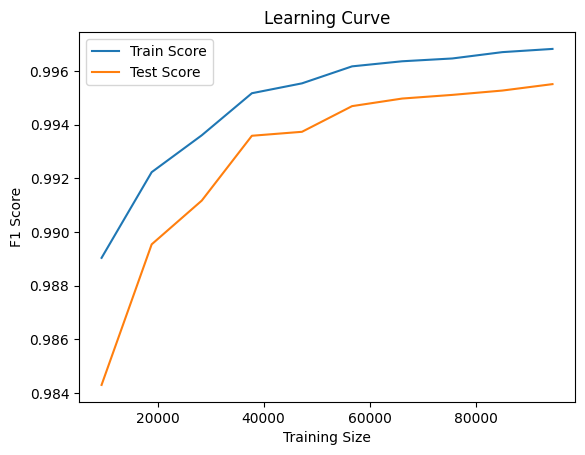

Evaluating XGBoost...
confusion matrix:
 [[9275  436]
 [4577 8256]]
classification report:
               precision    recall  f1-score   support

           0       0.67      0.96      0.79      9711
           1       0.95      0.64      0.77     12833

    accuracy                           0.78     22544
   macro avg       0.81      0.80      0.78     22544
weighted avg       0.83      0.78      0.78     22544



c:\oussama\me and my m\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [14] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\oussama\me and my m\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\oussama\me and my m\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [14] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\oussama\me and my m\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\oussama\me and my m\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [14] are constant.
  warnings.warn("Features %s are constant." % constant_feature

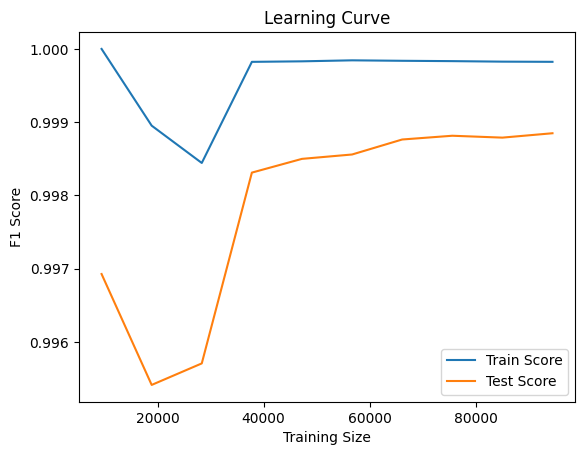

Evaluating RandomForest...
confusion matrix:
 [[9277  434]
 [4512 8321]]
classification report:
               precision    recall  f1-score   support

           0       0.67      0.96      0.79      9711
           1       0.95      0.65      0.77     12833

    accuracy                           0.78     22544
   macro avg       0.81      0.80      0.78     22544
weighted avg       0.83      0.78      0.78     22544



c:\oussama\me and my m\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [14] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\oussama\me and my m\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\oussama\me and my m\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [14] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\oussama\me and my m\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\oussama\me and my m\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [14] are constant.
  warnings.warn("Features %s are constant." % constant_feature

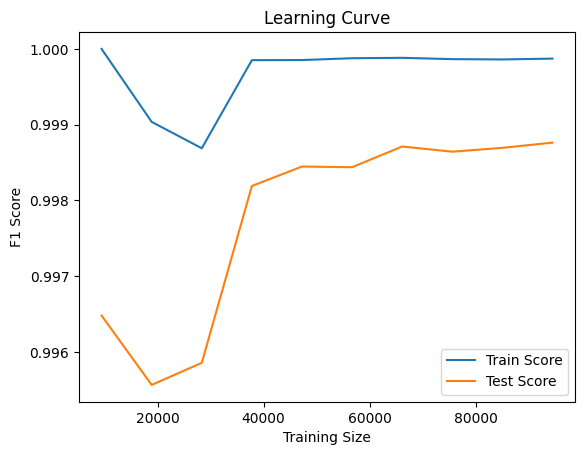

Evaluating DecisionTree...
confusion matrix:
 [[8751  960]
 [3208 9625]]
classification report:
               precision    recall  f1-score   support

           0       0.73      0.90      0.81      9711
           1       0.91      0.75      0.82     12833

    accuracy                           0.82     22544
   macro avg       0.82      0.83      0.81     22544
weighted avg       0.83      0.82      0.82     22544



c:\oussama\me and my m\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [14] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\oussama\me and my m\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\oussama\me and my m\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [14] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\oussama\me and my m\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\oussama\me and my m\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [14] are constant.
  warnings.warn("Features %s are constant." % constant_feature

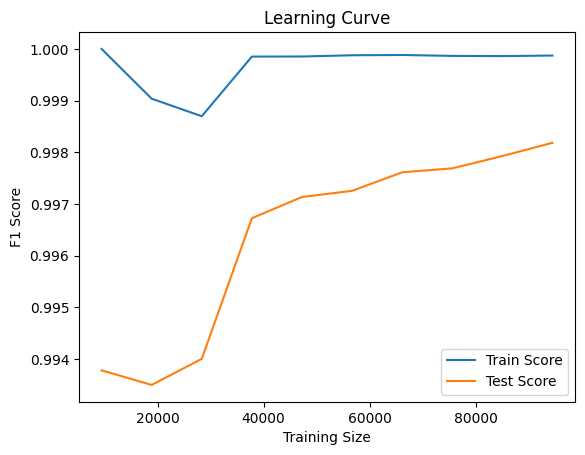

In [93]:
KNN=make_pipeline(preprocessor, KNeighborsClassifier())
SVM=make_pipeline(preprocessor, SVC(random_state=42))
XGboost=make_pipeline(preprocessor, XGBClassifier(random_state=42))
RandomForest=make_pipeline(preprocessor, RandomForestClassifier(random_state=42))
DecisionTree = make_pipeline(preprocessor, DecisionTreeClassifier(random_state=42))
dict_models = {
    'KNN': KNN,
    'XGBoost': XGboost,
    'RandomForest': RandomForest,
    'DecisionTree': DecisionTree
}
for name, model in dict_models.items():
    print(f"Evaluating {name}...")
    evaluation(model)

In [90]:
print(DecisionTree)

Pipeline(steps=[('pipeline',
                 Pipeline(steps=[('selectkbest', SelectKBest(k=25))])),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(random_state=42))])


In [92]:
param_grid = {
    'decisiontreeclassifier__max_depth': range(3, 14, 1),
    'decisiontreeclassifier__min_samples_split': [1,2,3,4,5,10],
    'pipeline__selectkbest__k': range(1,31)
}
grid_search_dt = RandomizedSearchCV(DecisionTree, param_grid, cv=5, scoring='recall', n_iter=50, random_state=42,n_jobs=-1, verbose=1)
grid_search_dt.fit(X_train, y_train)
print("Best Hyperparameters for Decision Tree:", grid_search_dt.best_params_)
print("classification report for best Decision Tree (KDDTrain+):\n", classification_report(y_test, grid_search_dt.predict(X_test)))
prediction(grid_search_dt.best_estimator_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


c:\oussama\me and my m\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
30 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "c:\oussama\me and my m\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\oussama\me and my m\.venv\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\oussama\me and my m\.venv\Lib\site-packages\sklearn\pipeline.py", line 621, in fit
    self._fi

Best Hyperparameters for Decision Tree: {'pipeline__selectkbest__k': 24, 'decisiontreeclassifier__min_samples_split': 10, 'decisiontreeclassifier__max_depth': 12}
classification report for best Decision Tree (KDDTrain+):
               precision    recall  f1-score   support

           0       0.67      0.91      0.77      9711
           1       0.91      0.66      0.76     12833

    accuracy                           0.77     22544
   macro avg       0.79      0.78      0.77     22544
weighted avg       0.80      0.77      0.77     22544

confusion matrix:
 [[8842  869]
 [4403 8430]]
classification report (KDDTest+):
               precision    recall  f1-score   support

           0       0.67      0.91      0.77      9711
           1       0.91      0.66      0.76     12833

    accuracy                           0.77     22544
   macro avg       0.79      0.78      0.77     22544
weighted avg       0.80      0.77      0.77     22544

accuracy score:
 0.7661462029808375
f1 scor

In [94]:
# Version légère
param_grid = {
    'kneighborsclassifier__n_neighbors': [1,3, 5, 7, 11],
    'kneighborsclassifier__weights': ['uniform', 'distance'],
    'kneighborsclassifier__metric': ['euclidean', 'manhattan'],
    'pipeline__selectkbest__k': range(15,31)
}
grid_search_knn = RandomizedSearchCV(KNN, param_grid, cv=4, scoring='f1', n_iter=40, random_state=42,n_jobs=-1, verbose=1)
grid_search_knn.fit(X_train, y_train)
print("Best Hyperparameters for KNN:", grid_search_knn.best_params_)
print("classification report for best KNN (KDDTrain+):\n", classification_report(y_test, grid_search_knn.predict(X_test)))
prediction(grid_search_knn.best_estimator_)

Fitting 4 folds for each of 40 candidates, totalling 160 fits
Best Hyperparameters for KNN: {'pipeline__selectkbest__k': 25, 'kneighborsclassifier__weights': 'distance', 'kneighborsclassifier__n_neighbors': 1, 'kneighborsclassifier__metric': 'manhattan'}
classification report for best KNN (KDDTrain+):
               precision    recall  f1-score   support

           0       0.64      0.93      0.76      9711
           1       0.92      0.61      0.74     12833

    accuracy                           0.75     22544
   macro avg       0.78      0.77      0.75     22544
weighted avg       0.80      0.75      0.75     22544

confusion matrix:
 [[9029  682]
 [4978 7855]]
classification report (KDDTest+):
               precision    recall  f1-score   support

           0       0.64      0.93      0.76      9711
           1       0.92      0.61      0.74     12833

    accuracy                           0.75     22544
   macro avg       0.78      0.77      0.75     22544
weighted avg    

In [139]:
dict_hyperparameters = {'pipeline__selectkbest__k': [28], 'xgbclassifier__n_estimators': [180], 'xgbclassifier__learning_rate': [0.03], 'xgbclassifier__max_depth': [3]}
from sklearn.model_selection import GridSearchCV
grid_search = RandomizedSearchCV(XGboost, dict_hyperparameters, cv=KFold(n_splits=7), scoring='f1', n_iter=100, random_state=42)
grid_search.fit(X_train, y_train)
print("Best Hyperparameters:", grid_search.best_params_)
print("classification report for best XGBoost:\n", classification_report(y_test, grid_search.predict(X_test)))
evaluation(grid_search.best_estimator_)
model_presque_final = grid_search.best_estimator_

c:\oussama\me and my m\.venv\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 1 is smaller than n_iter=100. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\oussama\me and my m\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [14] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\oussama\me and my m\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Best Hyperparameters: {'xgbclassifier__n_estimators': 180, 'xgbclassifier__max_depth': 3, 'xgbclassifier__learning_rate': 0.03, 'pipeline__selectkbest__k': 28}
classification report for best XGBoost:
               precision    recall  f1-score   support

           0       0.75      0.85      0.80      9711
           1       0.87      0.79      0.83     12833

    accuracy                           0.81     22544
   macro avg       0.81      0.82      0.81     22544
weighted avg       0.82      0.81      0.81     22544

confusion matrix:
 [[ 8248  1463]
 [ 2748 10085]]
classification report:
               precision    recall  f1-score   support

           0       0.75      0.85      0.80      9711
           1       0.87      0.79      0.83     12833

    accuracy                           0.81     22544
   macro avg       0.81      0.82      0.81     22544
weighted avg       0.82      0.81      0.81     22544



Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
       'num_compromised', 'su_attempted', 'num_file_creations',
       'num_access_files', 'is_host_login', 'serror_rate', 'rerror_rate',
       'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
       'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
       'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
       'dst_host_rerror_rate', 'attack', 'bytes_ratio', 'error_ratio',
       'log_src_bytes', 'log_dst_bytes', 'log_duration'],
      dtype='str')

In [141]:
y_pred_test = model_presque_final.predict(X)
print('accuracy score:\n', accuracy_score(Y, y_pred_test))

accuracy score:
 0.8132097232079489


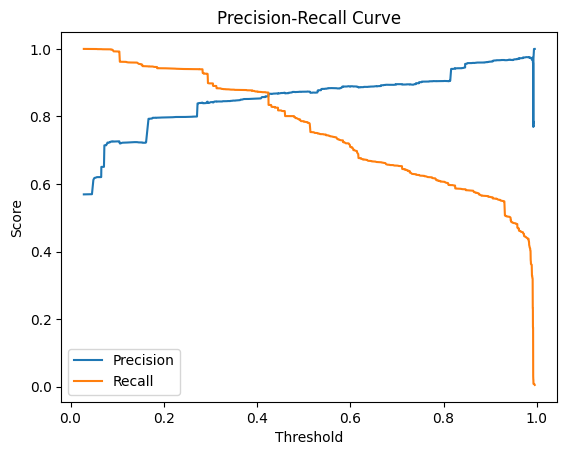

best threshold: 0.28296185


In [143]:
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_test, model_presque_final.predict_proba(X_test)[:,1])
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()
print("best threshold:", thresholds[np.argmax(precision[:-1] + recall[:-1])])

In [153]:
from sklearn.metrics import recall_score, precision_score, f1_score
def model_final(model,threshold,X_test):
    return model.predict_proba(X_test)[:,1] >= threshold

y_pred_final = model_final(model_presque_final, thresholds[np.argmax(precision[:-1] + recall[:-1])], X_test)
print('classification report for final model:\n', classification_report(y_test, y_pred_final))

classification report for final model:
               precision    recall  f1-score   support

           0       0.91      0.77      0.83      9711
           1       0.84      0.94      0.89     12833

    accuracy                           0.86     22544
   macro avg       0.87      0.85      0.86     22544
weighted avg       0.87      0.86      0.86     22544

